<a href="https://colab.research.google.com/github/cheongchoonsing1234-commits/Customer-Churn-Prediction-Using-Machine-Learning/blob/main/AAW_318_APPLIED_BUSINESS_ANALYTICS_PROJECTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Librarian

In [9]:
# Load data analysis libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Set style
sns.set_style('whitegrid')

# Load Data

In [10]:
# Load datasets
features_df = pd.read_csv('/content/drive/MyDrive/kaggle/input/ecommerce_customer_features.csv')
targets_df = pd.read_csv('/content/drive/MyDrive/kaggle/input/ecommerce_customer_targets.csv')

# Merge them on Customer_ID
df = pd.merge(features_df, targets_df, on='Customer_ID')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (6000, 16)


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


# Data Preparation

# Exploratory Data Analysis (EDA)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [12]:
df.describe()


,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


# Data Preprocessing

NOTE: Drop ID + check missing values + label encoding



In [13]:
# drop Customer_ID as it is not a predictive feature
df_clean = df.drop(['Customer_ID'], axis=1)
print("Customer_ID column removed successfully.")

# Check for missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

# Display overall result
if missing_values.sum() == 0:
    print("\nResult: No missing values were found in the dataset.")
else:
    print(f"\nResult: A total of {missing_values.sum()} missing values were detected in the dataset.")

Customer_ID column removed successfully.

Missing values in each column:
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

Result: No missing values were found in the dataset.


# Label Encoding


In [14]:
# encode loyalty_member: Yes = 1, No = 0
df_clean['loyalty_member'] = df_clean['loyalty_member'].map({'Yes': 1, 'No': 0})

# encode churned (target): Yes = 1, No = 0
df_clean['churned'] = df_clean['churned'].map({'Yes': 1, 'No': 0})

df_clean.head(15)

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0
5,18,62.28,5,13,0.565,0.0544,2,0,0.0,0.680,3.30,4.52,6.79,6.6,0
6,20,25.01,6,9,0.225,0.0528,1,0,1.1,0.492,4.51,5.12,8.67,4.4,0
7,43,50.97,11,116,0.095,0.0296,1,0,5.8,0.314,3.99,2.30,8.22,3.4,1
8,60,164.73,31,1,0.190,0.0048,0,0,1.9,0.551,3.33,6.62,8.31,3.3,0
9,58,65.91,15,4,0.341,0.0288,1,0,2.3,0.383,2.82,6.07,7.06,5.0,0


# Data Splitting

In [15]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target label (y)
X = df_clean.drop('churned', axis=1)
y = df_clean['churned']

# Split into 80% training and 20% test; stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

X_train shape: (4800, 14)
X_test shape : (1200, 14)


# Outlier Detection & Capping

Outlier Detection

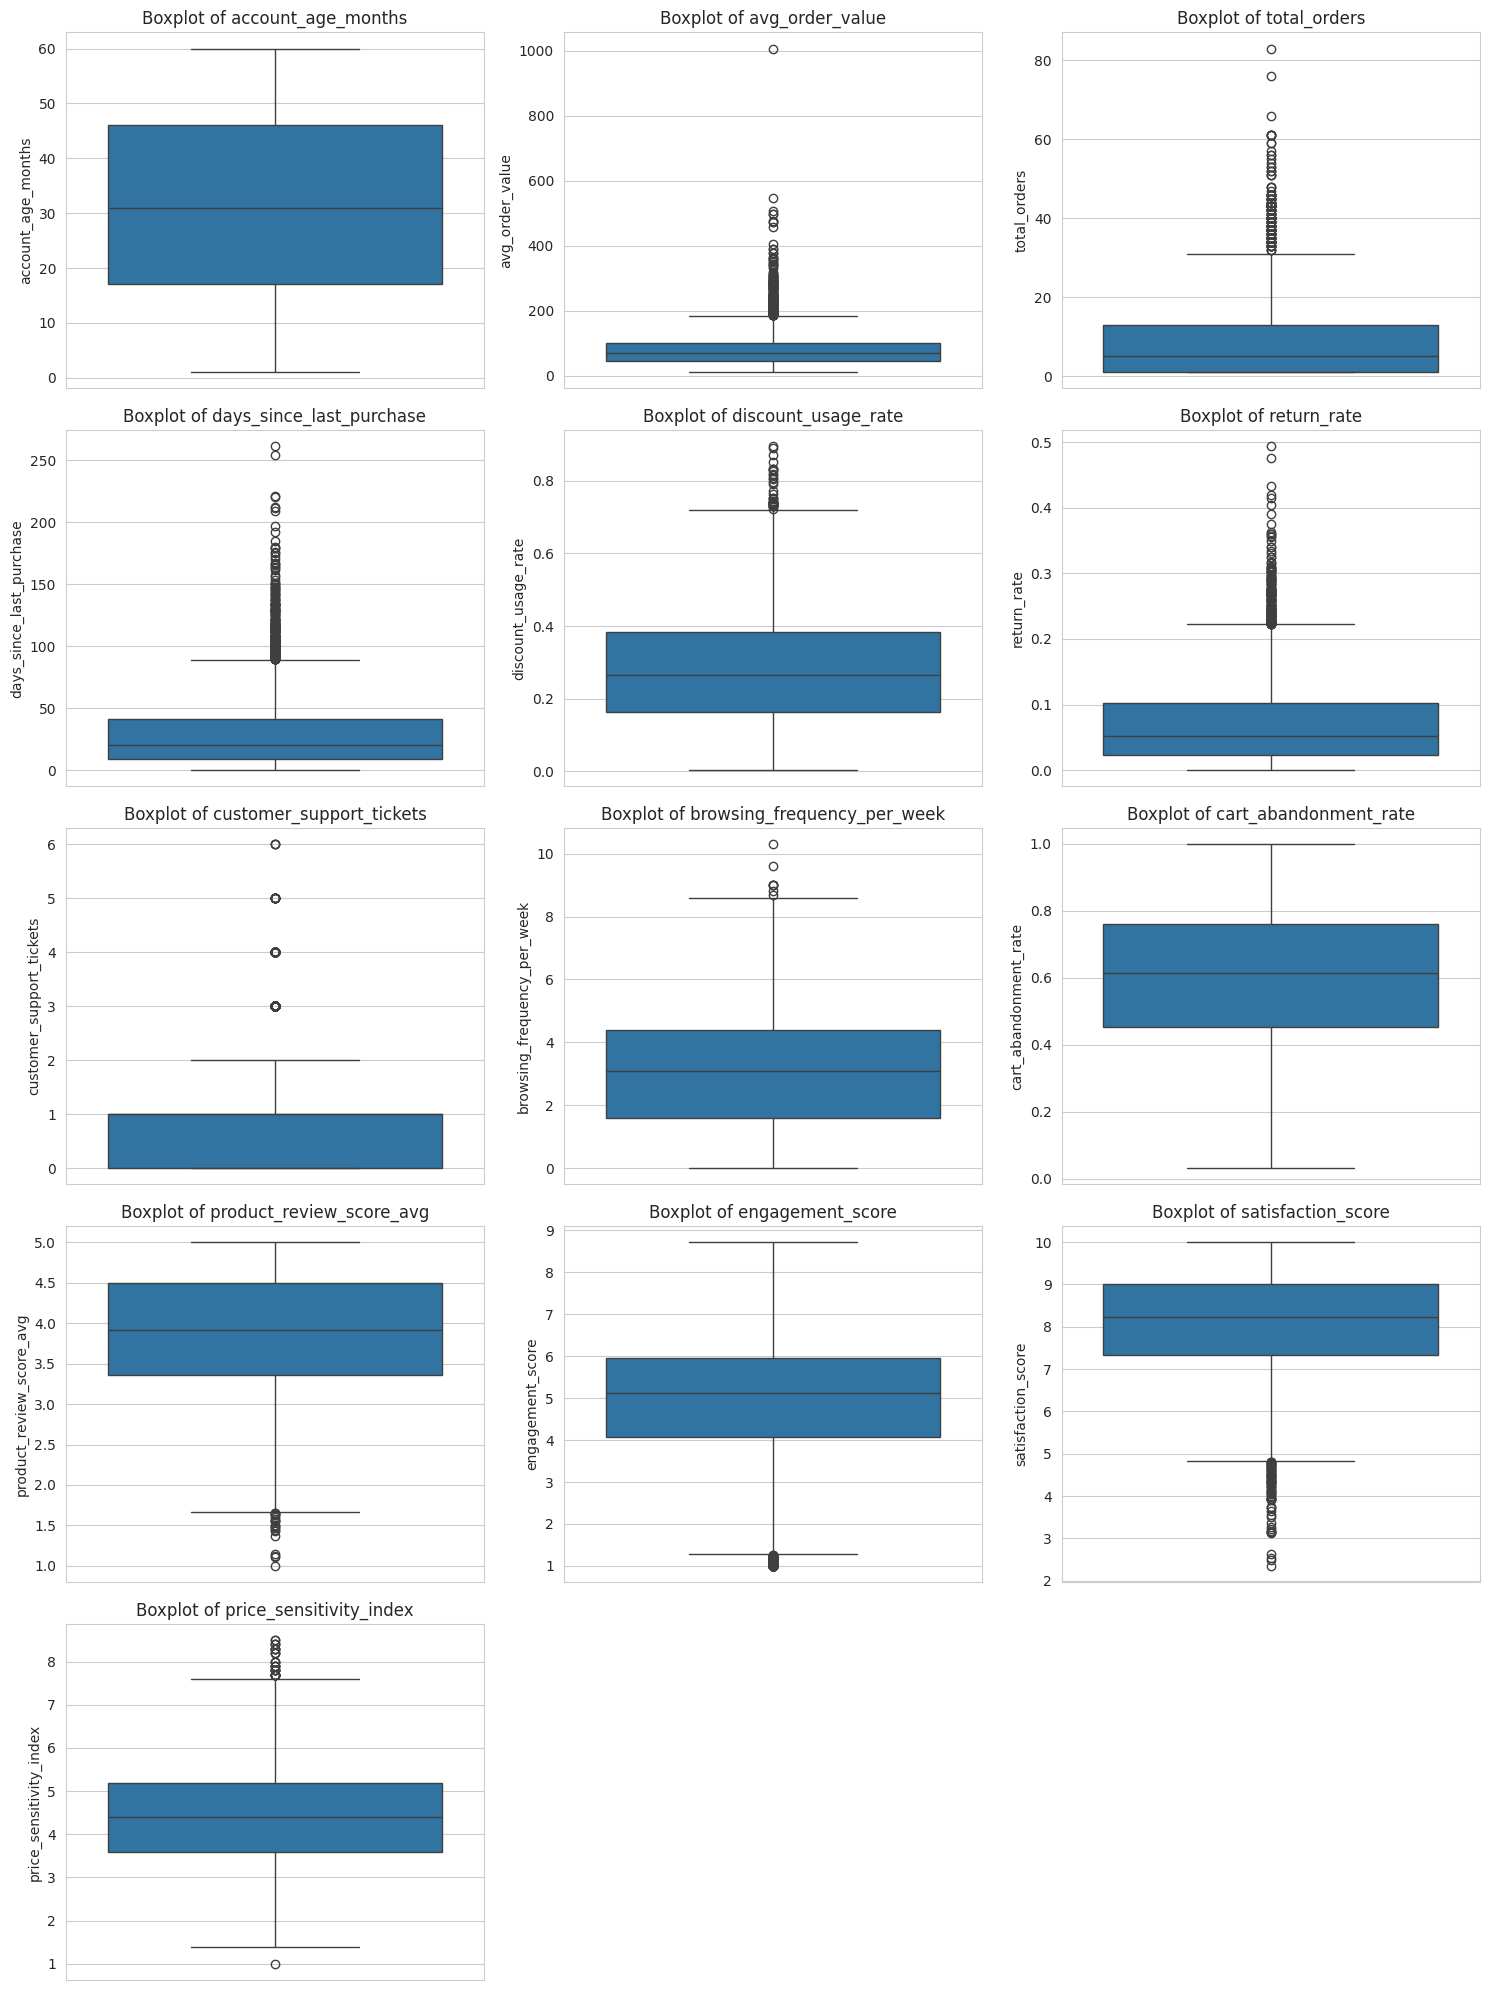

In [16]:
# Only look at numeric columns; binary columns don't have meaningful "outliers"
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'loyalty_member']

# Plot individual boxplots for each numeric feature to visually inspect spread and outliers
plt.figure(figsize=(15, 20))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i+1)
    sns.boxplot(y=X_train[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [17]:
# Calculate IQR-based outlier bounds using TRAINING data only (no test-set leakage)
outlier_bounds  = {}
outlier_summary = []

for col in numeric_cols:
    Q1  = X_train[col].quantile(0.25)
    Q3  = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    # Standard Tukey fences: anything beyond 1.5x IQR from Q1/Q3 is flagged
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = (lower, upper)

    # Count how many rows fall outside the bounds before any capping
    outlier_count = X_train[(X_train[col] < lower) | (X_train[col] > upper)].shape[0]
    outlier_pct   = (outlier_count / len(X_train)) * 100

    outlier_summary.append({
        'Column': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count (before capping)': outlier_count,
        'Outlier % (before capping)': round(outlier_pct, 2)
    })

summary_df = pd.DataFrame(outlier_summary).sort_values('Outlier Count (before capping)', ascending=False)
print('Outlier counts before capping:')
print(summary_df.to_string(index=False))

Outlier counts before capping:
                     Column  Lower Bound  Upper Bound  Outlier Count (before capping)  Outlier % (before capping)
   customer_support_tickets        -1.50         2.50                             327                        6.81
   days_since_last_purchase       -39.00        89.00                             240                        5.00
            avg_order_value       -39.26       184.35                             224                        4.67
                return_rate        -0.10         0.22                             172                        3.58
               total_orders       -17.00        31.00                             159                        3.31
           engagement_score         1.27         8.76                             131                        2.73
         satisfaction_score         4.81        11.53                              73                        1.52
        discount_usage_rate        -0.17         0.72    

Outlier Capping

In [18]:
# Apply IQR capping (Winsorization) using bounds learned from training data only
# The same bounds are applied to the test set to prevent data leakage
for col, (lower, upper) in outlier_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

# Re-check the training set to confirm capping worked (counts should now all be 0)
verify_summary = []
for col in numeric_cols:
    lower, upper  = outlier_bounds[col]
    outlier_count = X_train[(X_train[col] < lower) | (X_train[col] > upper)].shape[0]
    outlier_pct   = (outlier_count / len(X_train)) * 100

    verify_summary.append({
        'Column': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count (after capping)': outlier_count,
        'Outlier % (after capping)': round(outlier_pct, 2)
    })

verify_df = pd.DataFrame(verify_summary)
print('Outlier counts after capping:')
print(verify_df.to_string(index=False))

Outlier counts after capping:
                     Column  Lower Bound  Upper Bound  Outlier Count (after capping)  Outlier % (after capping)
         account_age_months       -26.50        89.50                              0                        0.0
            avg_order_value       -39.26       184.35                              0                        0.0
               total_orders       -17.00        31.00                              0                        0.0
   days_since_last_purchase       -39.00        89.00                              0                        0.0
        discount_usage_rate        -0.17         0.72                              0                        0.0
                return_rate        -0.10         0.22                              0                        0.0
   customer_support_tickets        -1.50         2.50                              0                        0.0
browsing_frequency_per_week        -2.60         8.60                     

# Feature Selection

In [19]:
# Train a Random Forest purely to rank feature importance — not used as the final model
rf_selector = RandomForestClassifier(random_state=42, n_estimators=100)
rf_selector.fit(X_train, y_train)

# Extract and sort each feature's importance score (higher = more predictive)
feat_importance = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print('Feature Importance Ranking (from training data):')
print(feat_importance.round(4))

Feature Importance Ranking (from training data):
engagement_score               0.4713
days_since_last_purchase       0.3161
satisfaction_score             0.0360
browsing_frequency_per_week    0.0257
product_review_score_avg       0.0244
cart_abandonment_rate          0.0184
return_rate                    0.0173
discount_usage_rate            0.0167
avg_order_value                0.0147
account_age_months             0.0146
price_sensitivity_index        0.0137
customer_support_tickets       0.0118
total_orders                   0.0112
loyalty_member                 0.0081
dtype: float64


In [20]:
# Drop features with importance below 0.01 — they contribute very little signal
low_importance    = feat_importance[feat_importance < 0.01].index.tolist()
selected_features = feat_importance[feat_importance >= 0.01].index.tolist()

print(f'Low importance features to drop: {low_importance}')
print(f'Selected features: {selected_features}')

# Apply the same feature subset to both train and test sets
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

print(f'X_train shape after feature selection: {X_train.shape}')
print(f'X_test shape after feature selection : {X_test.shape}')

Low importance features to drop: ['loyalty_member']
Selected features: ['engagement_score', 'days_since_last_purchase', 'satisfaction_score', 'browsing_frequency_per_week', 'product_review_score_avg', 'cart_abandonment_rate', 'return_rate', 'discount_usage_rate', 'avg_order_value', 'account_age_months', 'price_sensitivity_index', 'customer_support_tickets', 'total_orders']
X_train shape after feature selection: (4800, 13)
X_test shape after feature selection : (1200, 13)


# Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

# Initialise StandardScaler — transforms each feature to zero mean and unit variance
scaler = StandardScaler()

# Fit the scaler on training data only, then apply the same transform to test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert arrays back to DataFrames to retain column names and index
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

# Confirm scaling: mean ≈ 0 and std ≈ 1 for all features
X_train_scaled.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
engagement_score,4800.0,-0.0,1.0,-2.47,-0.56,0.16,0.72,2.61
days_since_last_purchase,4800.0,-0.0,1.0,-1.13,-0.77,-0.33,0.51,2.44
satisfaction_score,4800.0,0.0,1.0,-2.73,-0.64,0.12,0.76,1.58
browsing_frequency_per_week,4800.0,0.0,1.0,-1.63,-0.78,0.01,0.70,2.92
product_review_score_avg,4800.0,0.0,1.0,-2.89,-0.68,0.04,0.78,1.45
cart_abandonment_rate,4800.0,-0.0,1.0,-2.82,-0.73,0.07,0.79,1.97
return_rate,4800.0,-0.0,1.0,-1.17,-0.79,-0.28,0.56,2.58
discount_usage_rate,4800.0,-0.0,1.0,-1.80,-0.78,-0.12,0.65,2.79
avg_order_value,4800.0,-0.0,1.0,-1.55,-0.75,-0.22,0.53,2.46
account_age_months,4800.0,-0.0,1.0,-1.73,-0.81,-0.00,0.86,1.67


# Class Balancing with SMOTE

Before SMOTE: (4800, 13), class counts:
churned
0    4057
1     743
Name: count, dtype: int64

After SMOTE : (8114, 13), class counts:
churned
0    4057
1    4057
Name: count, dtype: int64


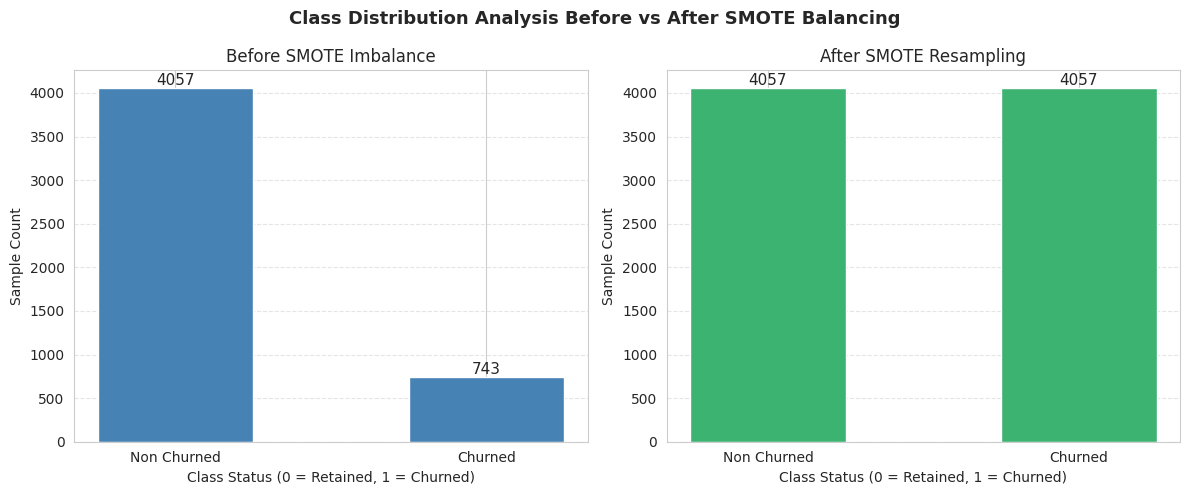

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {X_train_scaled.shape}, class counts:\n{y_train.value_counts()}')
print(f'\nAfter SMOTE : {X_train_smote.shape}, class counts:\n{y_train_smote.value_counts()}')

# %% [code]
before_counts = y_train.value_counts().sort_index()
after_counts  = y_train_smote.value_counts().sort_index()

labels = [f'Class {c}' for c in before_counts.index]
x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(x, before_counts.values, color='steelblue', edgecolor='white', width=0.5)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(bar.get_height()), ha='center', va='bottom', fontsize=11)
ax1.set_title('Before SMOTE Imbalance')
ax1.set_xlabel('Class Status (0 = Retained, 1 = Churned)')
ax1.set_ylabel('Sample Count')
ax1.set_xticks(x)
ax1.set_xticklabels(['Non Churned', 'Churned'])
ax1.grid(axis='y', linestyle='--', alpha=0.5)

bars2 = ax2.bar(x, after_counts.values, color='mediumseagreen', edgecolor='white', width=0.5)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(bar.get_height()), ha='center', va='bottom', fontsize=11)
ax2.set_title('After SMOTE Resampling')
ax2.set_xlabel('Class Status (0 = Retained, 1 = Churned)')
ax2.set_ylabel('Sample Count')
ax2.set_xticks(x)
ax2.set_xticklabels(['Non Churned', 'Churned'])
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Class Distribution Analysis Before vs After SMOTE Balancing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Model Training

Logistic Regression

Accuracy: 0.956

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.99      0.96      0.97      1014
     Churned       0.80      0.95      0.87       186

    accuracy                           0.96      1200
   macro avg       0.90      0.95      0.92      1200
weighted avg       0.96      0.96      0.96      1200



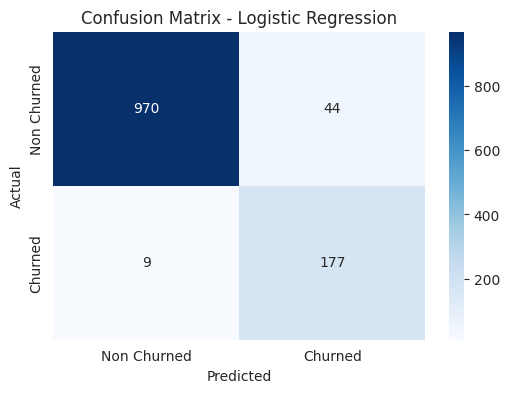

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

y_pred_lr = lr_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Decision Tree

Accuracy: 0.948

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.98      0.96      0.97      1014
     Churned       0.80      0.88      0.84       186

    accuracy                           0.95      1200
   macro avg       0.89      0.92      0.90      1200
weighted avg       0.95      0.95      0.95      1200



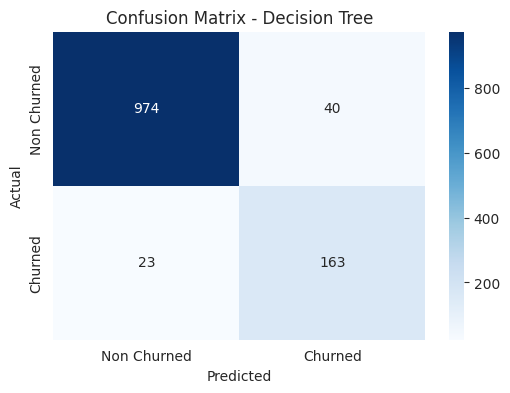

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Random Forest

Accuracy: 0.962

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.99      0.97      0.98      1014
     Churned       0.84      0.92      0.88       186

    accuracy                           0.96      1200
   macro avg       0.91      0.95      0.93      1200
weighted avg       0.96      0.96      0.96      1200



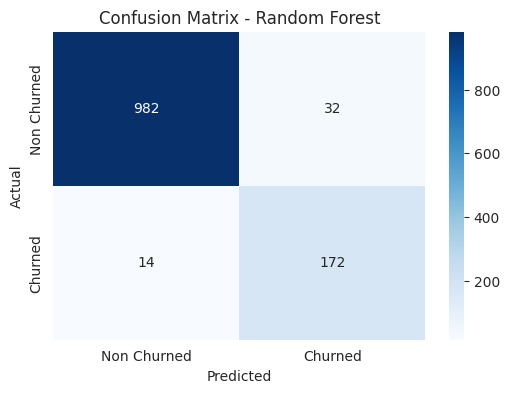

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Support Vector Machine (SVM)

Accuracy: 0.954

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.99      0.96      0.97      1014
     Churned       0.80      0.93      0.86       186

    accuracy                           0.95      1200
   macro avg       0.90      0.94      0.92      1200
weighted avg       0.96      0.95      0.96      1200



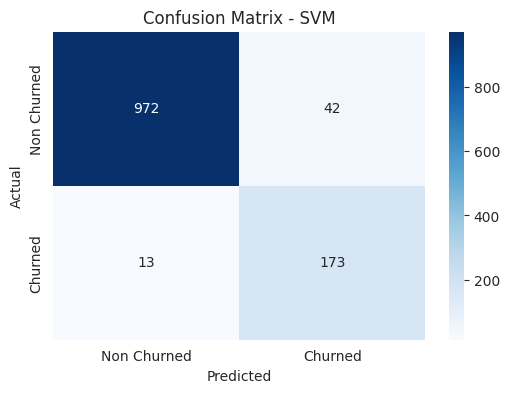

In [26]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42, kernel='rbf')
svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

K-Nearest Neighbors (KNN)

Accuracy: 0.937

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.99      0.93      0.96      1014
     Churned       0.73      0.95      0.82       186

    accuracy                           0.94      1200
   macro avg       0.86      0.94      0.89      1200
weighted avg       0.95      0.94      0.94      1200



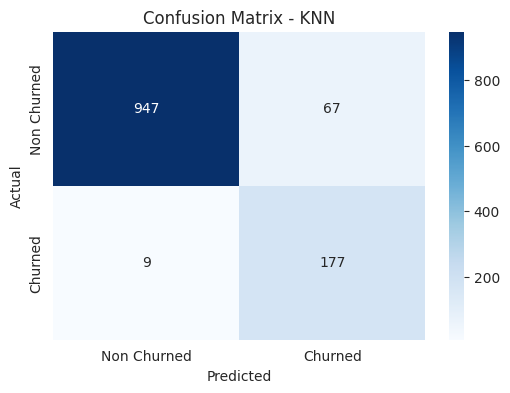

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_smote, y_train_smote)

y_pred_knn = knn_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

XGBoost

Accuracy: 0.962

Classification Report:
              precision    recall  f1-score   support

 Non Churned       0.98      0.97      0.98      1014
     Churned       0.86      0.89      0.88       186

    accuracy                           0.96      1200
   macro avg       0.92      0.93      0.93      1200
weighted avg       0.96      0.96      0.96      1200



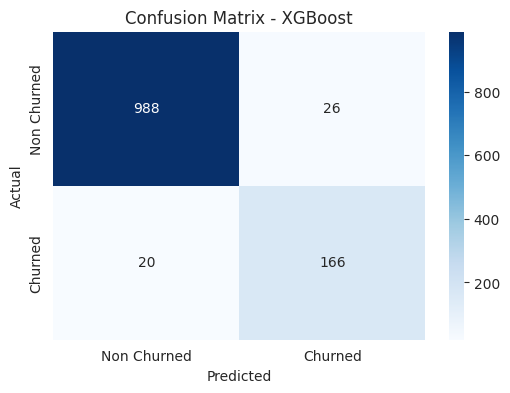

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Non Churned', 'Churned']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churned', 'Churned'],
            yticklabels=['Non Churned', 'Churned'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve Comparison



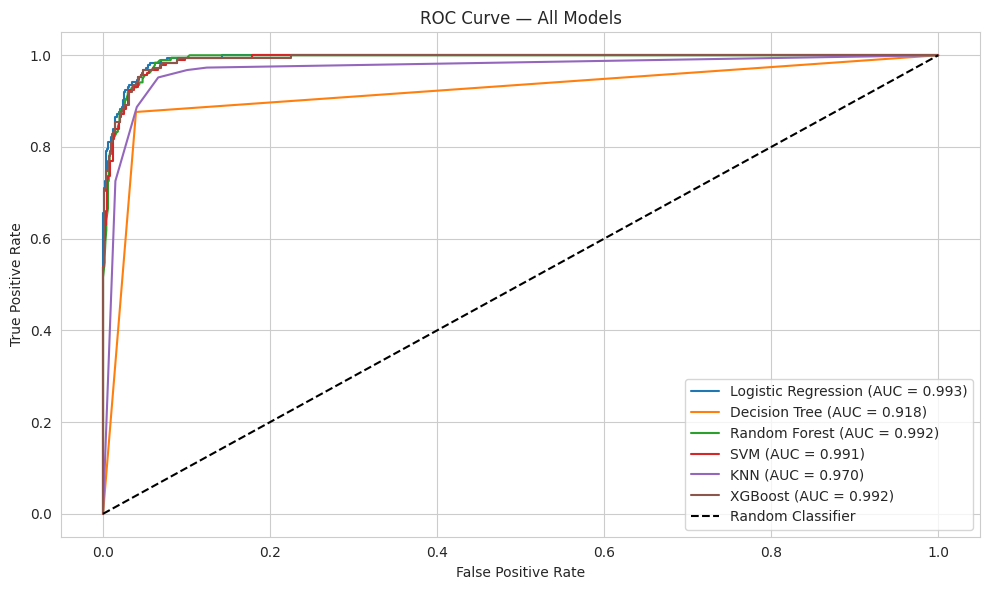

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Place this BEFORE "ROC Curve Comparison"
lr_probs  = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_probs  = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_probs  = rf_model.predict_proba(X_test_scaled)[:, 1]
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm_model.decision_function(X_test_scaled)

models_probs = {
    'Logistic Regression': lr_probs,
    'Decision Tree':       dt_probs,
    'Random Forest':       rf_probs,
    'SVM':                 svm_probs,
    'KNN':                 knn_probs,
    'XGBoost':             xgb_probs
}

# ROC curves — already in your notebook, kept here for reference alongside the metrics table
plt.figure(figsize=(10, 6))
for model_name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve — All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Model Comparison

In [30]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

# Predictions already computed: y_pred_lr, y_pred_dt, y_pred_rf, y_pred_svm, y_pred_knn, y_pred_xgb
# Probabilities already computed: lr_probs, dt_probs, rf_probs, knn_probs, xgb_probs, svm_probs (decision_function)

models_preds = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf,
    'SVM':                 y_pred_svm,
    'KNN':                 y_pred_knn,
    'XGBoost':             y_pred_xgb
}

models_probs = {
    'Logistic Regression': lr_probs,
    'Decision Tree':       dt_probs,
    'Random Forest':       rf_probs,
    'SVM':                 svm_probs,   # decision_function score, fine for AUC
    'KNN':                 knn_probs,
    'XGBoost':             xgb_probs
}

# Build full metrics table — focus on the "Churned" (positive) class for precision/recall/F1
results = []
for name, preds in models_preds.items():
    probs = models_probs[name]
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, pos_label=1),
        'Recall':    recall_score(y_test, preds, pos_label=1),
        'F1-Score':  f1_score(y_test, preds, pos_label=1),
        'AUC':       roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df = results_df.sort_values('F1-Score', ascending=False)

print('Model Performance Summary (Churned class = positive):')
print(results_df.to_string())

Model Performance Summary (Churned class = positive):
                     Accuracy  Precision  Recall  F1-Score    AUC
Model                                                            
Random Forest           0.962      0.843   0.925     0.882  0.992
XGBoost                 0.962      0.865   0.892     0.878  0.992
Logistic Regression     0.956      0.801   0.952     0.870  0.993
SVM                     0.954      0.805   0.930     0.863  0.991
Decision Tree           0.948      0.803   0.876     0.838  0.918
KNN                     0.937      0.725   0.952     0.823  0.970


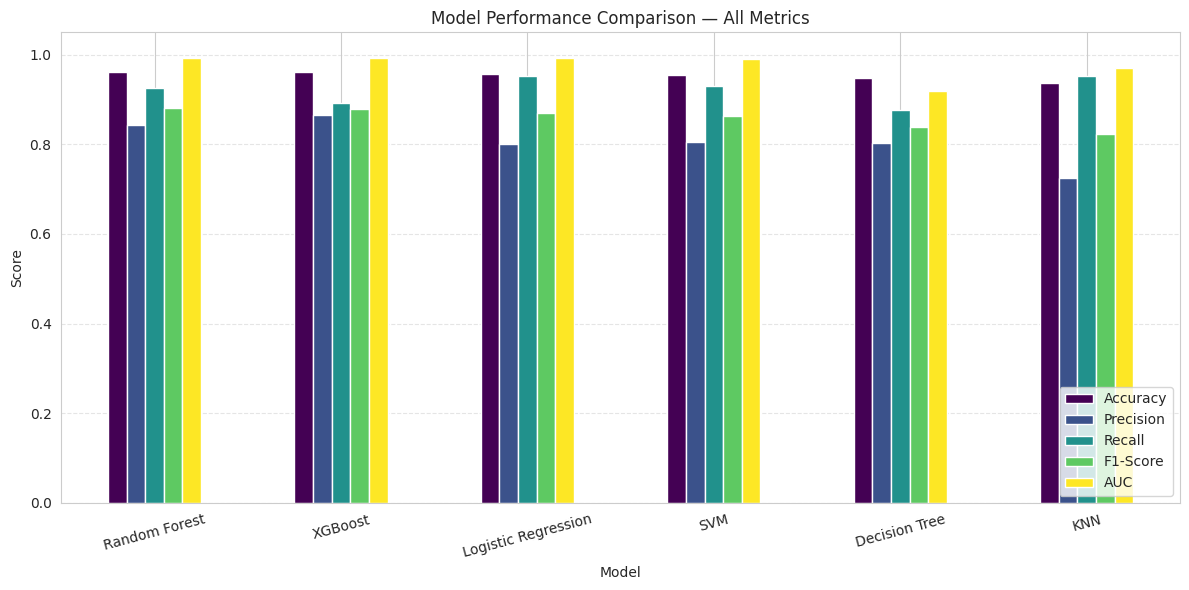

In [31]:
# Visual comparison across all 5 metrics
results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='white')
plt.title('Model Performance Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
# Champion selection: rank by F1-Score first (balances precision & recall on the churn class),
# use AUC as the tiebreaker since it reflects ranking quality across all thresholds
results_df['Rank_Score'] = results_df['F1-Score'] + (results_df['AUC'] * 0.001)  # tiny AUC nudge to break exact ties
champion = results_df['Rank_Score'].idxmax()

print(f'Champion Model: {champion}')
print(f'\nFull metrics for {champion}:')
print(results_df.loc[champion, ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']])

Champion Model: Random Forest

Full metrics for Random Forest:
Accuracy     0.962
Precision    0.843
Recall       0.925
F1-Score     0.882
AUC          0.992
Name: Random Forest, dtype: float64


# SHAP Feature Importance (RANDOM_FOREST)



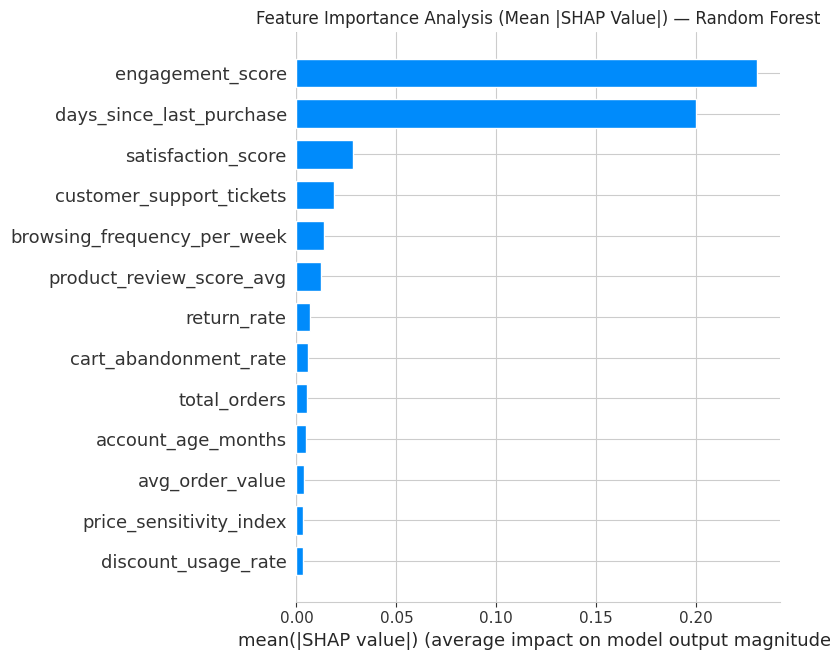

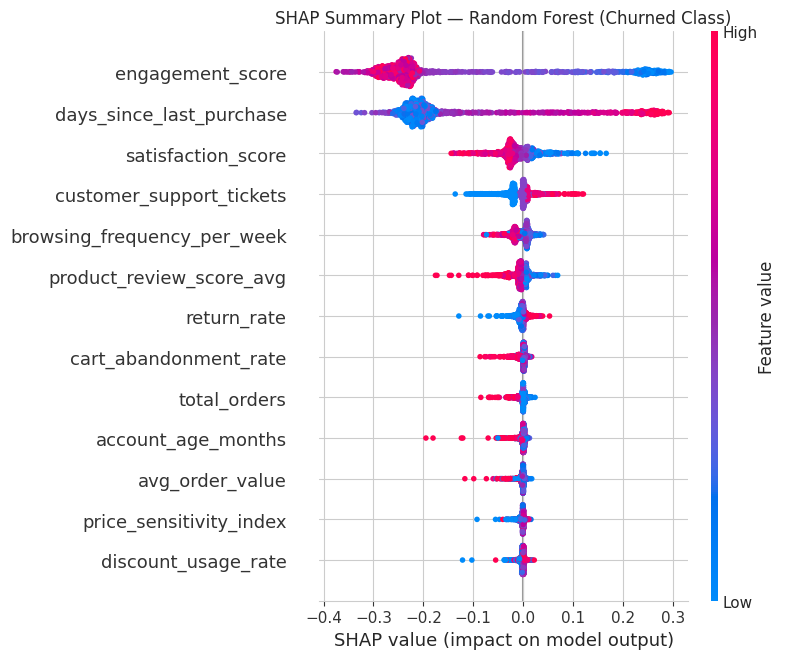

In [33]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Future-proof check for both old (list) and new (3D array) SHAP output formats
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

# --- Feature Importance Analysis ---
# (plt.figure() removed as shap builds its own)
shap.summary_plot(shap_values_churn, X_test_scaled,
                   feature_names=X_test_scaled.columns.tolist(),
                   plot_type='bar',
                   show=False)
plt.title('Feature Importance Analysis (Mean |SHAP Value|) — Random Forest')
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot ---
shap.summary_plot(shap_values_churn, X_test_scaled,
                   feature_names=X_test_scaled.columns.tolist(),
                   show=False)
plt.title('SHAP Summary Plot — Random Forest (Churned Class)')
plt.tight_layout()
plt.show()